In [1]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow_hub

Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [29]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow_hub as hub
import os

from tensorflow import keras
from tensorflow.keras.applications.efficientnet import EfficientNetB7, preprocess_input
from tensorflow.keras.applications.efficientnet import EfficientNetB6, preprocess_input
from tensorflow.keras.applications.efficientnet import EfficientNetB5, preprocess_input
from tensorflow.keras.layers import InputLayer, Input, Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from keras.callbacks import CSVLogger

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from glob import glob

In [5]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
# set data directories
train_dir = os.path.join('C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets')

# lung adenocarcinoma path
lung_aca = os.path.join('C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_aca')

# lung benign path
lung_n = os.path.join('C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_n')

# lung squamos cell carcinoma path
lung_scc = os.path.join('C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_scc')

In [7]:
%%time
train_aca_names = os.listdir(lung_aca)
print(f'TRAIN SET ADENOCARCINOMA: {train_aca_names[:10]}')
print('\n')

train_n_names = os.listdir(lung_n)
print(f'TRAIN SET BENIGN: {train_n_names[:10]}')
print('\n')

train_scc_names = os.listdir(lung_scc)
print(f'TRAIN SET SQUAMOS CELL CARCINOMA: {train_scc_names[:10]}')

TRAIN SET ADENOCARCINOMA: ['lungaca1.jpeg', 'lungaca10.jpeg', 'lungaca100.jpeg', 'lungaca1000.jpeg', 'lungaca1001.jpeg', 'lungaca1002.jpeg', 'lungaca1003.jpeg', 'lungaca1004.jpeg', 'lungaca1005.jpeg', 'lungaca1006.jpeg']


TRAIN SET BENIGN: ['lungn1.jpeg', 'lungn10.jpeg', 'lungn100.jpeg', 'lungn1000.jpeg', 'lungn1001.jpeg', 'lungn1002.jpeg', 'lungn1003.jpeg', 'lungn1004.jpeg', 'lungn1005.jpeg', 'lungn1006.jpeg']


TRAIN SET SQUAMOS CELL CARCINOMA: ['lungscc1.jpeg', 'lungscc10.jpeg', 'lungscc100.jpeg', 'lungscc1000.jpeg', 'lungscc1001.jpeg', 'lungscc1002.jpeg', 'lungscc1003.jpeg', 'lungscc1004.jpeg', 'lungscc1005.jpeg', 'lungscc1006.jpeg']
CPU times: total: 31.2 ms
Wall time: 71.7 ms


In [8]:
print(f'total training Adenocarcinoma images: {len(os.listdir(lung_aca))}')
print(f'total training Benign images: {len(os.listdir(lung_n))}')
print(f'total training Squamous Cell Carcinoma images: {len(os.listdir(lung_scc))}')

# calculate number of training images
train_aca = len(os.listdir(lung_aca))
train_n = len(os.listdir(lung_n))
train_scc = len(os.listdir(lung_scc))
total = train_aca + train_n + train_scc

# print total number of images
print('Total Images in dataset: %s' % str((total))) 

total training Adenocarcinoma images: 5000
total training Benign images: 5000
total training Squamous Cell Carcinoma images: 5000
Total Images in dataset: 15000


In [9]:
print(f'total training Adenocarcinoma images: {len(os.listdir(lung_aca))}')
print(f'total training Benign images: {len(os.listdir(lung_n))}')
print(f'total training Squamous Cell Carcinoma images: {len(os.listdir(lung_scc))}')

# calculate number of training images
train_aca = len(os.listdir(lung_aca))
train_n = len(os.listdir(lung_n))
train_scc = len(os.listdir(lung_scc))
total = train_aca + train_n + train_scc

# print total number of images
print('Total Images in dataset: %s' % str((total))) 

total training Adenocarcinoma images: 5000
total training Benign images: 5000
total training Squamous Cell Carcinoma images: 5000
Total Images in dataset: 15000


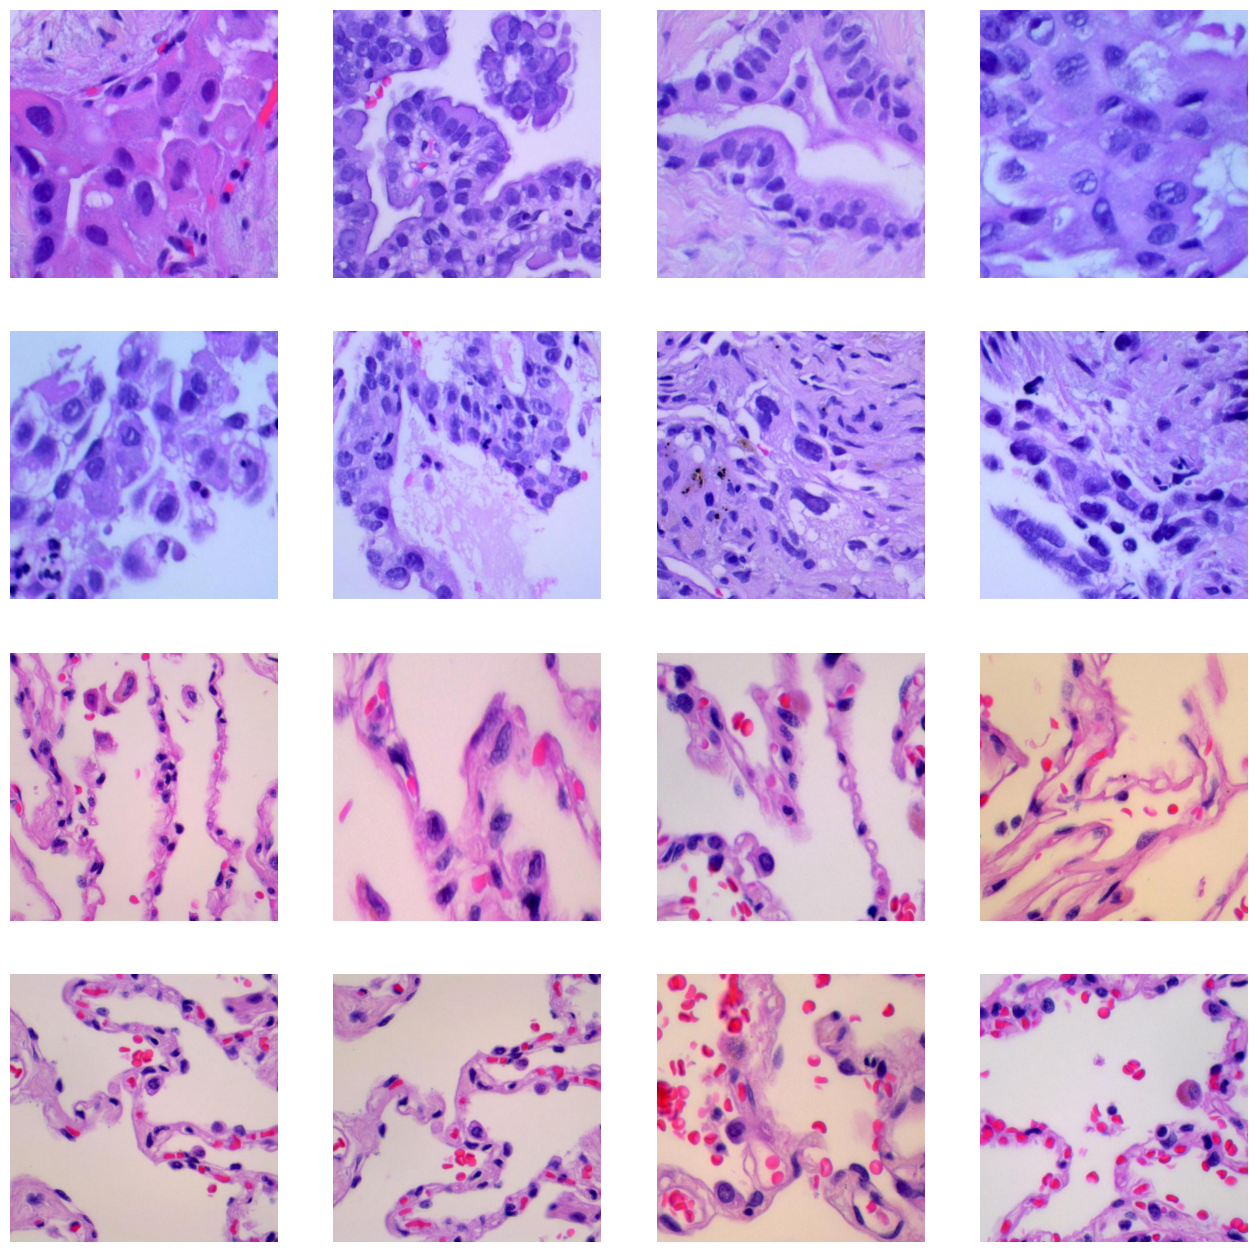

In [10]:
# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8
next_aca_pix = [os.path.join(lung_aca, fname) 
                for fname in train_aca_names[pic_index-8:pic_index]]

next_n_pix = [os.path.join(lung_n, fname) 
                for fname in train_n_names[pic_index-8:pic_index]]

for i, img_path in enumerate(next_aca_pix + next_n_pix):
    
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

In [11]:
%%time

data_dir = 'C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets'

# making a data split of 80-20
data = ImageDataGenerator(validation_split = 0.2)

# setting up the batch size
BATCH_SIZE = 128

# setting up the image size
X = Y = 224

# making training dataset
train_data = data.flow_from_directory(data_dir,
                                    class_mode = "categorical",
                                    target_size = (X, Y),
                                    color_mode="rgb",
                                    batch_size = BATCH_SIZE, 
                                    shuffle = False,
                                    subset='training',
                                    seed = 42)

# making validation dataset
val_data = data.flow_from_directory(data_dir,
                                      class_mode = "categorical",
                                      target_size = (X, Y),
                                      color_mode="rgb",
                                      batch_size = BATCH_SIZE, 
                                      shuffle = False,
                                      subset='validation',
                                      seed = 42)

Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
CPU times: total: 641 ms
Wall time: 1.4 s


In [12]:
# print label names
label =  {0: "lung adenocarcinoma", 1: "benign", 2: "squamous cell carcinoma"}
for t in label.keys():
    print(t, label[t])

0 lung adenocarcinoma
1 benign
2 squamous cell carcinoma


In [13]:
# initializing efficientnet b7 cnn model
eff_5 = EfficientNetB5 (
        input_shape=(X, Y, 3),
        weights='imagenet',
        include_top=False
        )

# setting trainable to false    
eff_5.trainable = False

# global avg pooling layer
x = GlobalAveragePooling2D()(eff_5.output)
# flatten layer
x = Flatten()(x)
# fully connected layer 1
x = Dense(128, activation='relu')(x)
# fully connected layer 2
x = Dense(64, activation='relu')(x)

# outout layer
y = Dense(3, activation='softmax')(x) # since we have three outputs, we will use 3 neurons in last layer

# setting up y = f(x)
# tie it together
model_efb5 = Model(inputs=eff_5.input, 
              outputs=y)

In [1]:
#model_efb5.summary()

In [15]:
model_efb5.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [16]:
model_efb5

<Functional name=functional_1, built=True>

In [17]:
class myCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs={}):
            if logs.get('val_accuracy') >= 0.9800:
                print('\nReached 98.00% accuracy so cancelling training!')
                self.model.stop_training=True
                
callbacks = myCallback()

In [18]:
# setting up early stopping to stop training when max acc is reached
# we are using validation loss as parameter for monitoring the training process

early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=3)

logger = CSVLogger('logs_efb5.csv', append=True)

EPOCHS = 15

# fitting the model to training data
history = model_efb5.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[callbacks, logger]
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1640s 16s/step - accuracy: 0.6622 - loss: 0.6520 - val_accuracy: 0.9377 - val_loss: 0.1741
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1573s 17s/step - accuracy: 0.9156 - loss: 0.2068 - val_accuracy: 0.9507 - val_loss: 0.1265
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1432s 15s/step - accuracy: 0.9413 - loss: 0.1572 - val_accuracy: 0.9503 - val_loss: 0.1239
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1393s 15s/step - accuracy: 0.9555 - loss: 0.1143 - val_accuracy: 0.9747 - val_loss: 0.0699
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1397s 15s/step - accuracy: 0.9641 - loss: 0.0969 - val_accuracy: 0.9503 - val_loss: 0.1164
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1394s 15s/step - accuracy: 0.9578 - loss: 0.1048 - val_accuracy: 0.9763 - val_loss: 0.0578
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1402s 15s/step - accuracy: 0.9767 - loss: 0.0628 - val_accuracy: 0.9703 - val_loss: 0.0753
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9704 - loss: 0.0708 
Reached 98.0

In [19]:
# calculate model history
hist = history.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [22]:
# save the model
model_efb5.save('efficient_model.h5')

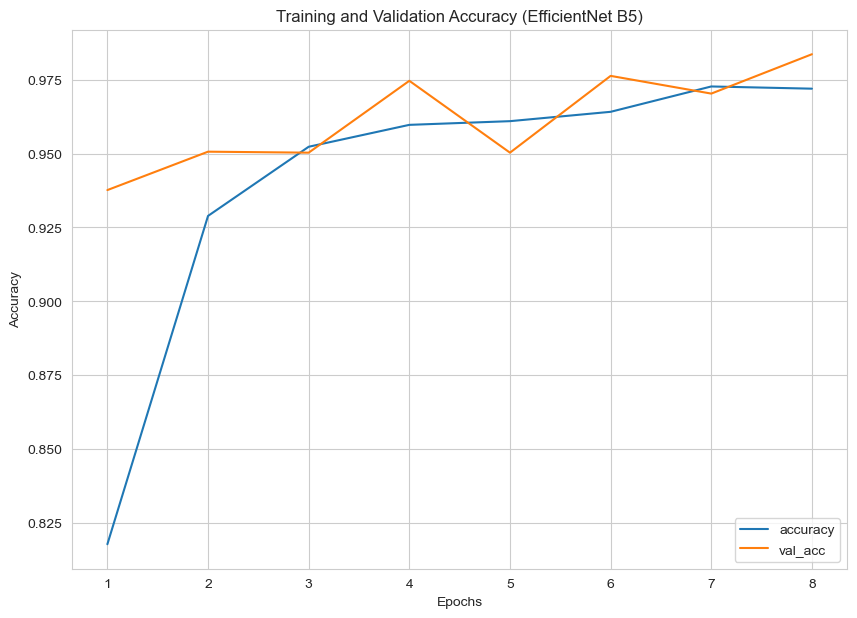

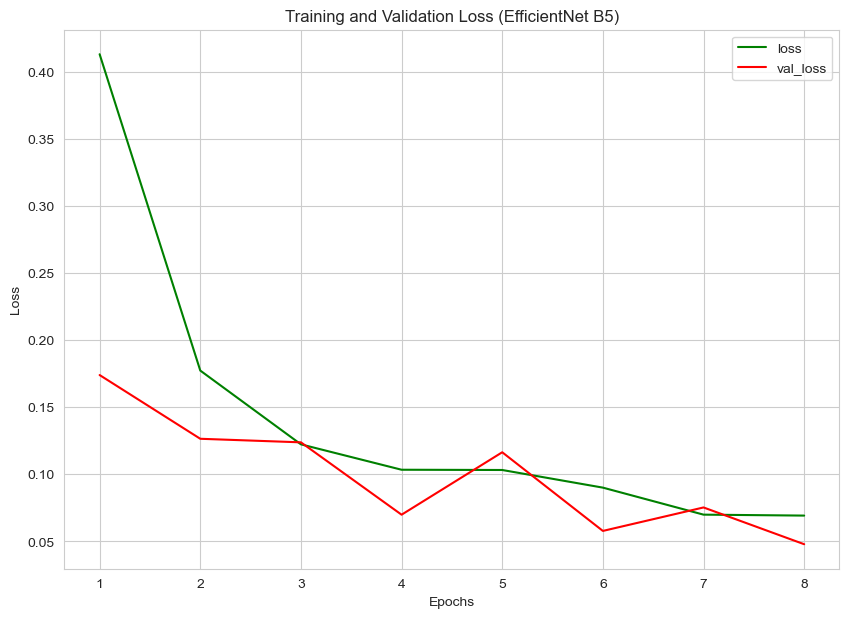

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

epochs = range(1, len(hist['loss']) + 1)
acc = hist['accuracy']
loss = hist['loss']
val_acc = hist['val_accuracy']
val_loss = hist['val_loss']

# Plot accuracy
plt.figure(figsize=(10, 7))
plt.title('Training and Validation Accuracy (EfficientNet B5)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, acc, label='accuracy')
plt.plot(epochs, val_acc, label='val_acc')
plt.legend(loc='lower right')

# Plot validation versus accuracy
plt.figure(figsize=(10, 7))
plt.title('Training and Validation Loss (EfficientNet B5)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, loss, label='loss', color='g')
plt.plot(epochs, val_loss, label='val_loss', color='r')
plt.legend()

plt.show()


In [23]:
# calculate result of validation data
scores = model_efb5.evaluate(val_data)
print("%s: %.2f%%" % (model_efb5.metrics_names[1], scores[1] * 100))

24/24 ━━━━━━━━━━━━━━━━━━━━ 297s 12s/step - accuracy: 0.9721 - loss: 0.0739
compile_metrics: 98.37%


In [26]:
# saving the model
model_efb5.save('model_optimized_99.87acc.h5')

In [27]:
y_hat = model_efb5.predict(val_data)
y_pred = np.argmax(y_hat, axis=1)

# print classification report
print(classification_report(val_data.classes, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 330s 13s/step
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1000
           1       1.00      1.00      1.00      1000
           2       0.96      0.99      0.98      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



Confusion matrix, without normalization


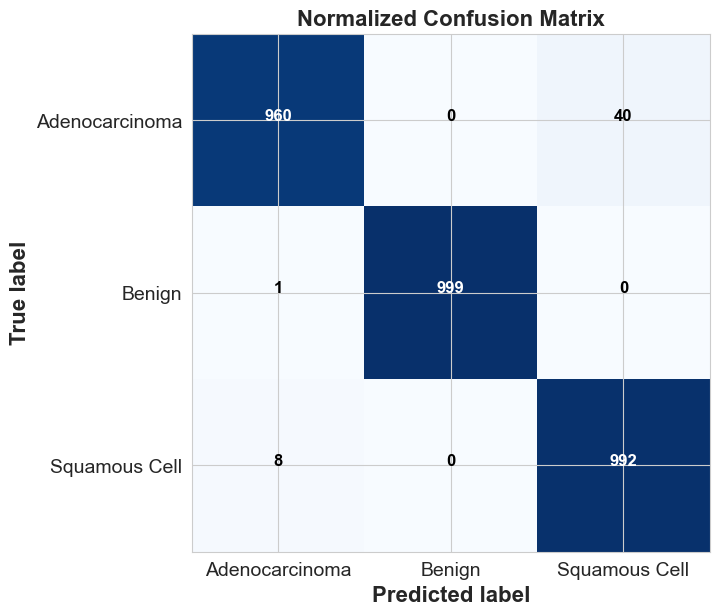

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# Your other code...

# Now you can use itertools in your plot_confusion_matrix function.

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=12, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

# computing confusion matrix
cnf_matrix = confusion_matrix(val_data.classes, y_pred)
np.set_printoptions(precision=2)

# plotting non-normalized confusion matrix
plt.figure(figsize=(10, 6))
plot_confusion_matrix(cnf_matrix, classes=['Adenocarcinoma', 'Benign', 'Squamous Cell'],
                      normalize=False,
                      title='Normalized Confusion Matrix')
plt.show()

In [31]:
from keras.preprocessing import image
path = 'C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_n/lungn986.jpeg'
# path_2 = '../input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca10.jpeg'
my_image = mpimg.imread(path)
img = image.load_img(path, target_size=(224, 224))

In [32]:
img = image.img_to_array(img)
x = np.expand_dims(img, axis=0)
x.shape

(1, 224, 224, 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
[1]
benign


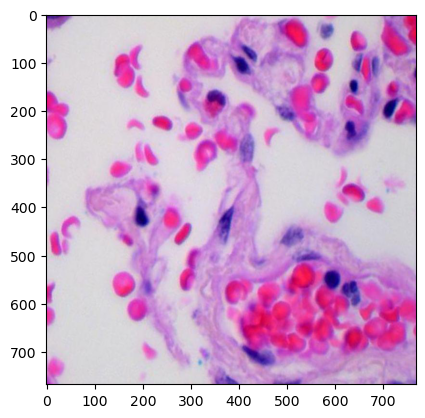

In [33]:
classes = np.argmax(model_efb5.predict(x), axis=1)
print(classes)
print(label[classes[0]])
plt.style.use('default')
plt.imshow(my_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
[0]
lung adenocarcinoma


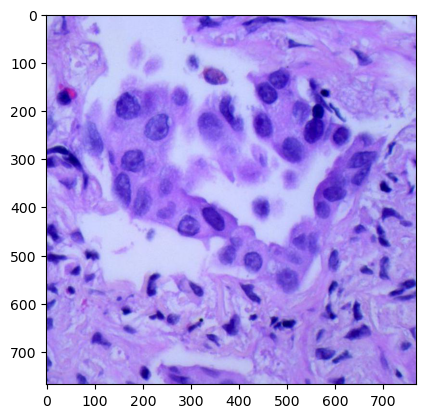

In [34]:
from keras.preprocessing import image
path = "C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_aca/lungaca993.jpeg"
# path_2 = '../input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca10.jpeg'
my_image = mpimg.imread(path)
img = image.load_img(path, target_size=(224, 224))
img = image.img_to_array(img)
x = np.expand_dims(img, axis=0)
x.shape
classes = np.argmax(model_efb5.predict(x), axis=1)
print(classes)
print(label[classes[0]])
plt.style.use('default')
plt.imshow(my_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
[2]
squamous cell carcinoma


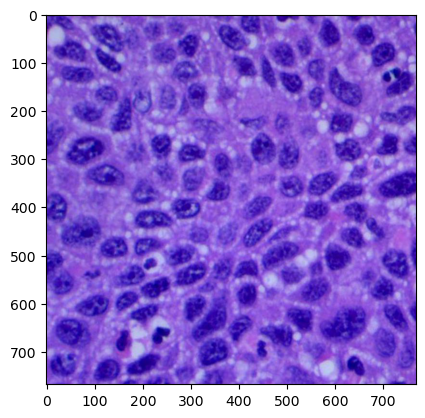

In [35]:
from keras.preprocessing import image
path ="C:/Users/HP/Downloads/archive/lung_colon_image_set/lung_image_sets/lung_scc/lungscc978.jpeg"
# path_2 = '../input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca10.jpeg'
my_image = mpimg.imread(path)
img = image.load_img(path, target_size=(224, 224))
img = image.img_to_array(img)
x = np.expand_dims(img, axis=0)
x.shape
classes = np.argmax(model_efb5.predict(x), axis=1)
print(classes)
print(label[classes[0]])
plt.style.use('default')
plt.imshow(my_image)

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset creation for demonstration purposes
# In practice, replace this with loading your actual dataset e.g., data = pd.read_csv('data.csv')
np.random.seed(42)
data = pd.DataFrame({
    'Feature1': np.random.randn(100),
    'Feature2': np.random.randn(100) * 2,
    'Feature3': np.random.randn(100) * 3,
    'Feature4': np.random.randn(100) + 2
})

# Compute the correlation matrix
correlation_matrix = data.corr()

# Display the correlation matrix
correlation_matrix


,Feature1,Feature2,Feature3,Feature4
Feature1,1.000000,-0.136422,0.190840,-0.170227
Feature2,-0.136422,1.000000,-0.036632,-0.017613
Feature3,0.190840,-0.036632,1.000000,-0.000259
Feature4,-0.170227,-0.017613,-0.000259,1.000000


              Feature1      Feature2      Feature3      Feature4
Feature1  1.000000e+00 -1.000000e+00  1.000000e+00  2.503858e-16
Feature2 -1.000000e+00  1.000000e+00 -1.000000e+00 -1.502315e-16
Feature3  1.000000e+00 -1.000000e+00  1.000000e+00 -3.004629e-16
Feature4  2.503858e-16 -1.502315e-16 -3.004629e-16  1.000000e+00


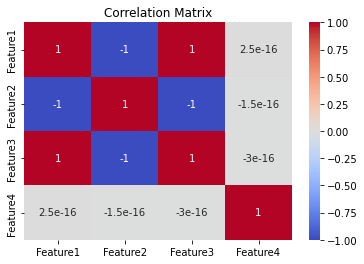

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data
data = {
    'Feature1': [0.5, 0.6, 0.7, 0.8, 0.9],
    'Feature2': [0.4, 0.3, 0.2, 0.1, 0.0],
    'Feature3': [1.1, 1.2, 1.3, 1.4, 1.5],
    'Feature4': [0.2, 0.3, 0.2, 0.3, 0.2]
}

# Creating DataFrame
df = pd.DataFrame(data)

# Compute the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
